# Diabetes Health Indicators – Machine Learning Project

This notebook covers the full ML pipeline:
1. Load and inspect the dataset
2. Preprocess the data
3. Exploratory Data Analysis (EDA)
4. Split data for training/testing
5. Train and evaluate baseline models
6. Hyperparameter tuning
7. Save final models

## Phase 1: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Phase 2: Load and Inspect the Data

In [3]:
# load the dataset
df = pd.read_csv('../data/raw/diabetes_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [5]:
# check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasti

In [6]:
# basic statistics
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [7]:
# identify target columns
targets = ['diagnosed_diabetes', 'diabetes_stage', 'diabetes_risk_score']

print('Binary target:', df['diagnosed_diabetes'].value_counts().to_dict())
print('\nMulticlass target:', df['diabetes_stage'].value_counts().to_dict())
print('\nRegression target stats:')
print(df['diabetes_risk_score'].describe())

Binary target: {1: 59998, 0: 40002}

Multiclass target: {'Type 2': 59774, 'Pre-Diabetes': 31845, 'No Diabetes': 7981, 'Gestational': 278, 'Type 1': 122}

Regression target stats:
count    100000.000000
mean         30.222362
std           9.061505
min           2.700000
25%          23.800000
50%          29.000000
75%          35.600000
max          67.200000
Name: diabetes_risk_score, dtype: float64


## Phase 3: Data Preprocessing

**Relevant columns for each task:**
- Binary Classification → `diagnosed_diabetes`
- Multiclass Classification → `diabetes_stage`
- Regression → `diabetes_risk_score`

In [8]:
# separate features from all three targets
X_raw = df.drop(columns=targets)

# identify numeric and categorical columns
num_cols = X_raw.select_dtypes(include='number').columns.tolist()
cat_cols = X_raw.select_dtypes(exclude='number').columns.tolist()

print('Numeric features:', num_cols)
print('\nCategorical features:', cat_cols)

Numeric features: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']

Categorical features: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


In [9]:
# impute missing values (none here, but good practice)
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_num = pd.DataFrame(num_imputer.fit_transform(X_raw[num_cols]), columns=num_cols)
X_cat = pd.DataFrame(cat_imputer.fit_transform(X_raw[cat_cols]), columns=cat_cols)

# one-hot encode categorical columns
X_cat_encoded = pd.get_dummies(X_cat, columns=cat_cols)

# combine numeric and encoded categorical
X_processed = pd.concat([X_num, X_cat_encoded], axis=1)
print('Processed feature shape:', X_processed.shape)
X_processed.head()

Processed feature shape: (100000, 46)


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Current,smoking_status_Former,smoking_status_Never
0,58.0,0.0,215.0,5.7,7.9,7.9,0.0,0.0,0.0,30.5,...,True,False,False,True,False,False,False,False,False,True
1,48.0,1.0,143.0,6.7,6.5,8.7,0.0,0.0,0.0,23.1,...,False,True,False,True,False,False,False,False,True,False
2,60.0,1.0,57.0,6.4,10.0,8.1,1.0,0.0,0.0,22.2,...,False,True,False,False,False,False,True,False,False,True
3,74.0,0.0,49.0,3.4,6.6,5.2,0.0,0.0,0.0,26.8,...,False,False,False,False,True,False,False,False,False,True
4,46.0,1.0,109.0,7.2,7.4,5.0,0.0,0.0,0.0,21.2,...,False,True,False,False,True,False,False,False,False,True


In [10]:
# standardize features so all columns are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

print('Scaling done.')

Scaling done.


In [11]:
# encode multiclass target with LabelEncoder
le = LabelEncoder()
y_multi = le.fit_transform(df['diabetes_stage'])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# binary and regression targets are already numeric
y_binary = df['diagnosed_diabetes'].values
y_reg    = df['diabetes_risk_score'].values

Class mapping: {'Gestational': np.int64(0), 'No Diabetes': np.int64(1), 'Pre-Diabetes': np.int64(2), 'Type 1': np.int64(3), 'Type 2': np.int64(4)}


In [12]:
# save processed features to data/processed/
import os
os.makedirs('../data/processed', exist_ok=True)

pd.DataFrame(X_scaled, columns=X_processed.columns).to_csv('../data/processed/X_processed.csv', index=False)
pd.Series(y_binary, name='diagnosed_diabetes').to_csv('../data/processed/y_binary.csv', index=False)
pd.Series(y_multi,  name='diabetes_stage').to_csv('../data/processed/y_multi.csv', index=False)
pd.Series(y_reg,    name='diabetes_risk_score').to_csv('../data/processed/y_reg.csv', index=False)
print('Processed data saved.')

Processed data saved.


## Phase 4: Exploratory Data Analysis (EDA)

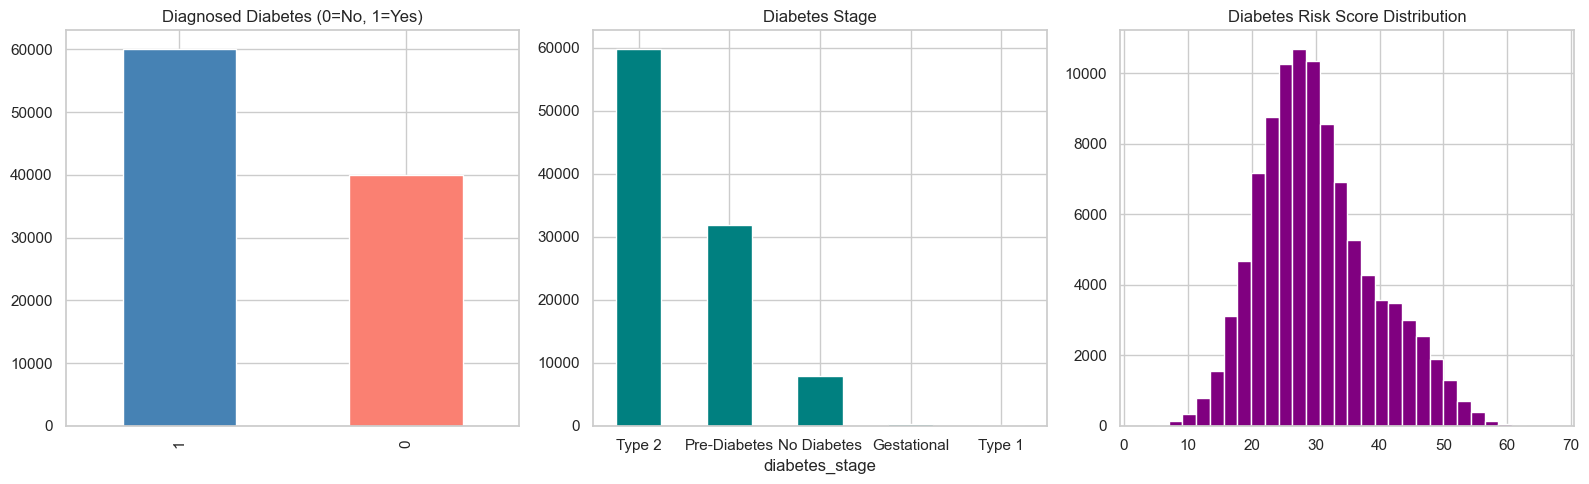

In [14]:
# distribution of all three targets
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['diagnosed_diabetes'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Diagnosed Diabetes (0=No, 1=Yes)')
axes[0].set_xlabel('')

df['diabetes_stage'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Diabetes Stage')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(df['diabetes_risk_score'], bins=30, color='purple', edgecolor='white')
axes[2].set_title('Diabetes Risk Score Distribution')

plt.tight_layout()
plt.show()

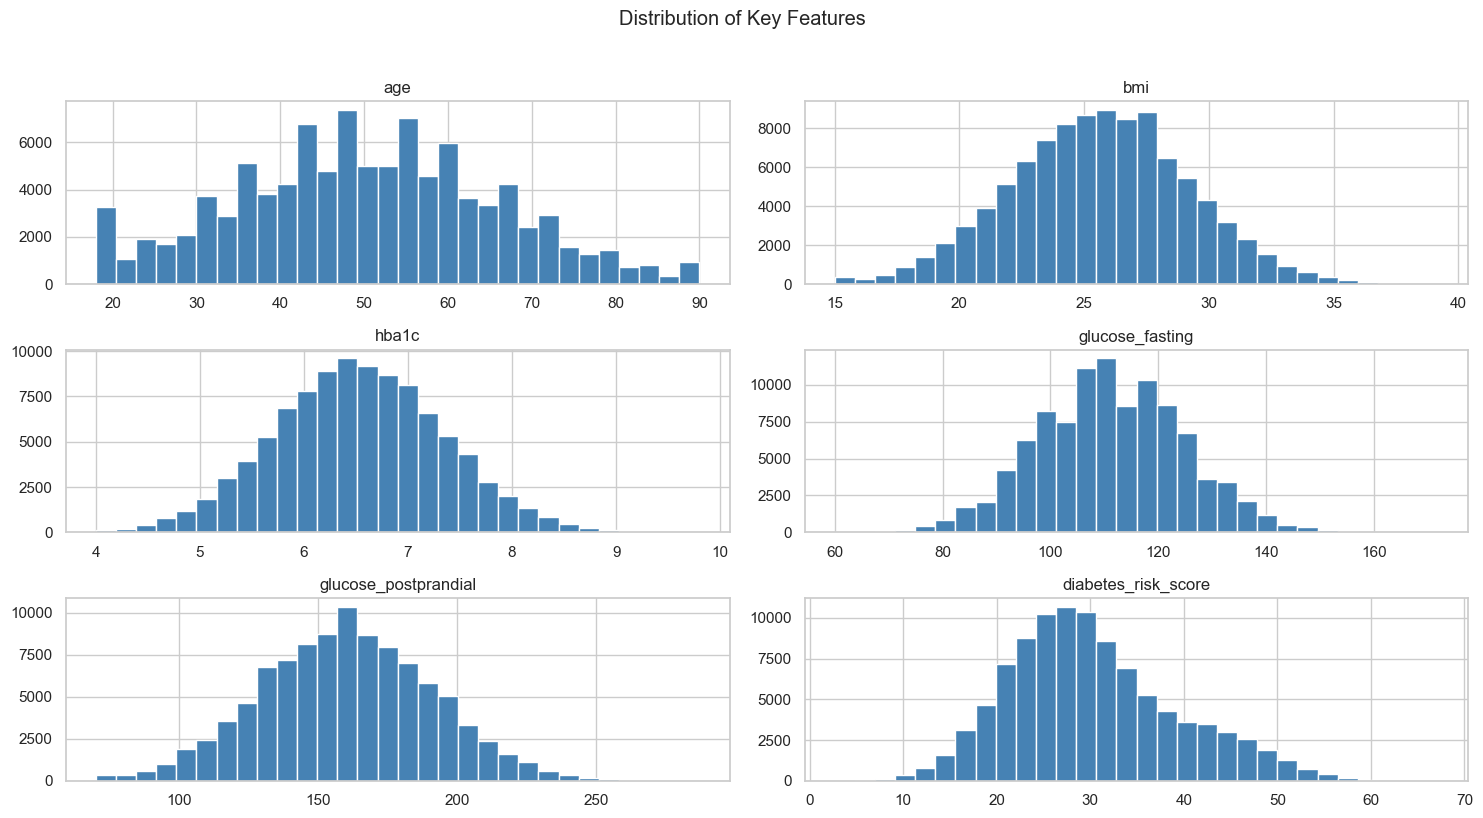

In [15]:
# histograms of key features
key_features = ['age', 'bmi', 'hba1c', 'glucose_fasting', 'glucose_postprandial', 'diabetes_risk_score']
df[key_features].hist(bins=30, figsize=(15, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Key Features', y=1.02)
plt.tight_layout()
plt.show()

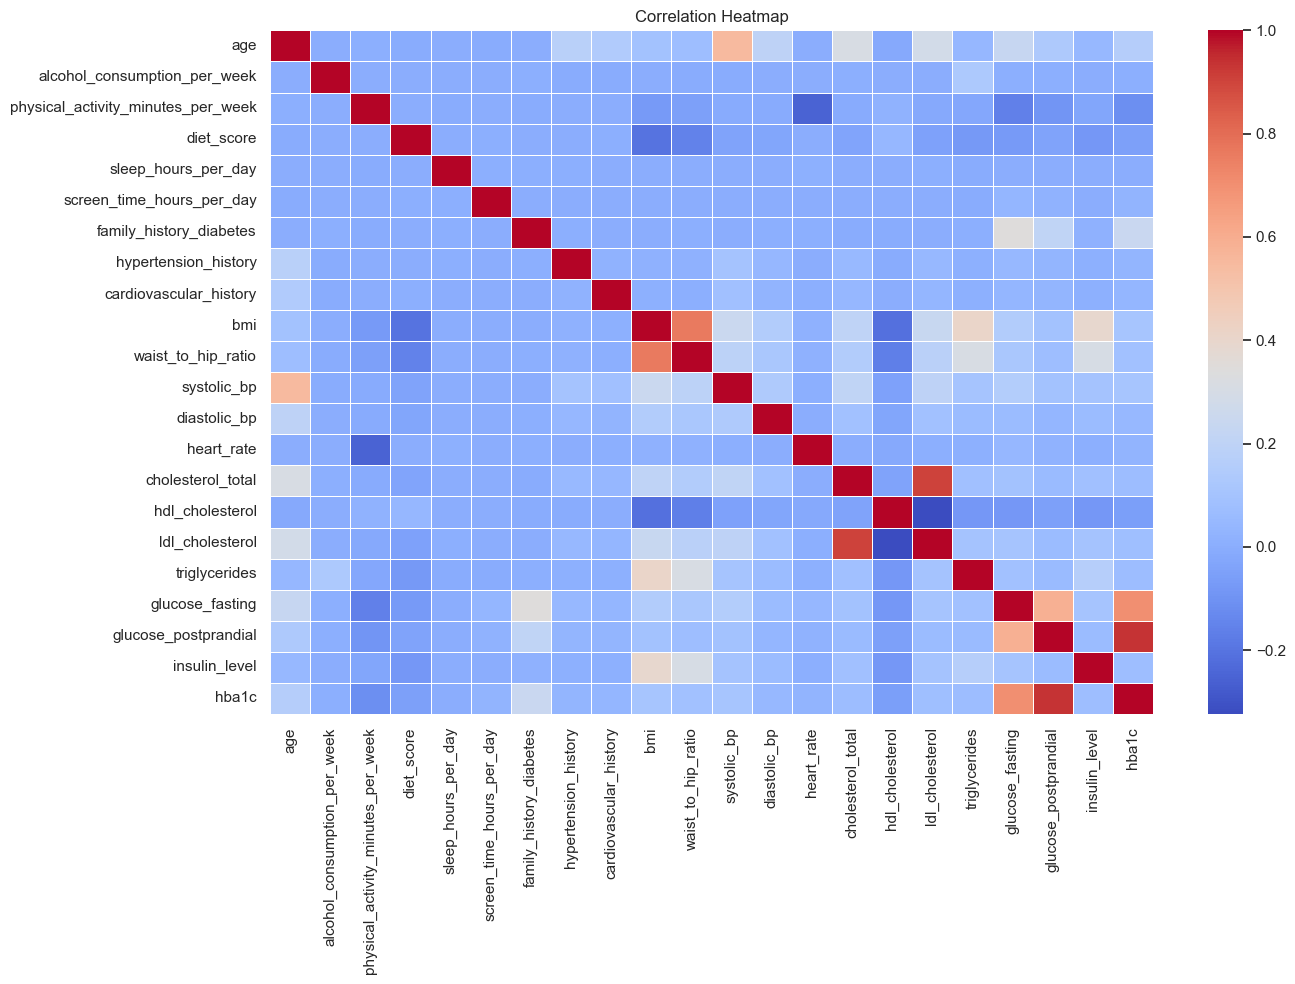

In [16]:
# correlation heatmap (numeric features only)
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

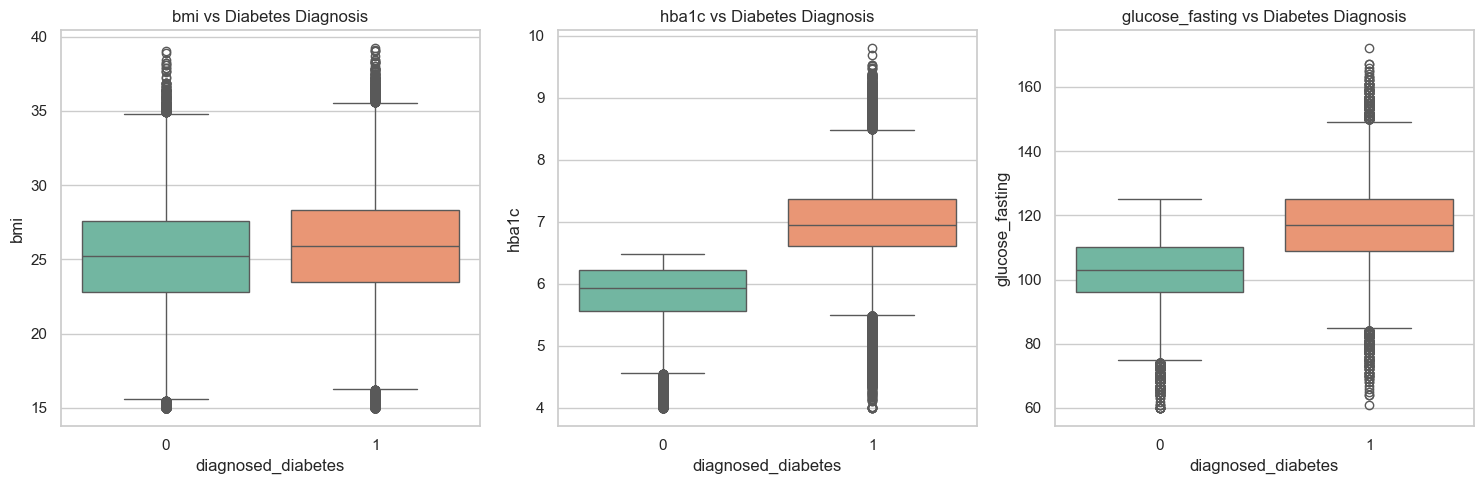

In [17]:
# boxplots: key features vs diabetes diagnosis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['bmi', 'hba1c', 'glucose_fasting']):
    sns.boxplot(x='diagnosed_diabetes', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Diabetes Diagnosis')

plt.tight_layout()
plt.show()

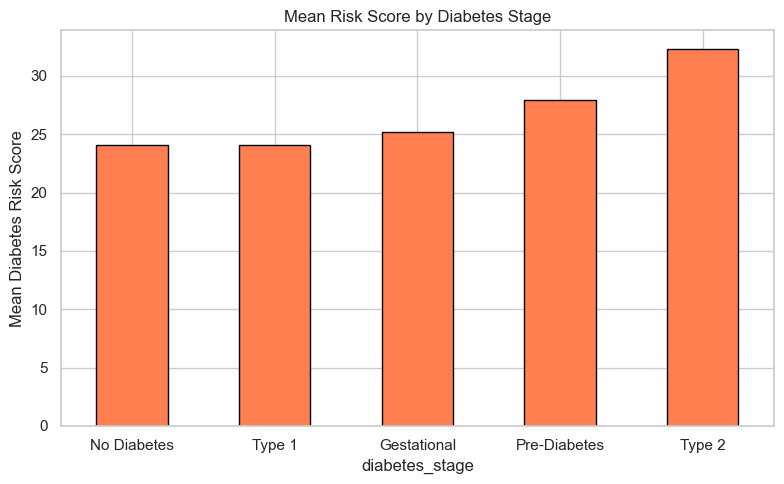

In [18]:
# group-wise comparison: mean risk score by diabetes stage
group_means = df.groupby('diabetes_stage')['diabetes_risk_score'].mean().sort_values()

plt.figure(figsize=(8, 5))
group_means.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Mean Risk Score by Diabetes Stage')
plt.ylabel('Mean Diabetes Risk Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Phase 5: Data Splitting

In [19]:
# binary classification split (stratified to keep class balance)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# multiclass classification split (stratified)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# regression split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

print('Binary    — Train:', X_train_b.shape, ' Test:', X_test_b.shape)
print('Multiclass — Train:', X_train_m.shape, ' Test:', X_test_m.shape)
print('Regression — Train:', X_train_r.shape, ' Test:', X_test_r.shape)

Binary    — Train: (80000, 46)  Test: (20000, 46)
Multiclass — Train: (80000, 46)  Test: (20000, 46)
Regression — Train: (80000, 46)  Test: (20000, 46)


## Phase 6: Baseline Model Training & Evaluation

### 6A – Binary Classification (`diagnosed_diabetes`)

In [20]:
# train three models for binary classification
lr_b  = LogisticRegression(max_iter=1000, random_state=42)
dt_b  = DecisionTreeClassifier(random_state=42)
knn_b = KNeighborsClassifier(n_neighbors=5)

for model in [lr_b, dt_b, knn_b]:
    model.fit(X_train_b, y_train_b)

print('Binary models trained.')

Binary models trained.


In [21]:
# evaluate binary models
binary_models = {'Logistic Regression': lr_b, 'Decision Tree': dt_b, 'KNN': knn_b}
binary_results = []

for name, model in binary_models.items():
    y_pred = model.predict(X_test_b)
    y_prob = model.predict_proba(X_test_b)[:, 1]
    binary_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_b, y_pred), 4),
        'Precision': round(precision_score(y_test_b, y_pred), 4),
        'Recall':    round(recall_score(y_test_b, y_pred), 4),
        'F1':        round(f1_score(y_test_b, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_b, y_prob), 4)
    })

pd.DataFrame(binary_results).set_index('Model')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8607,0.8755,0.8952,0.8852,0.9337
Decision Tree,0.8581,0.8736,0.8927,0.8830,0.8495
KNN,0.7630,0.7964,0.8127,0.8045,0.8274


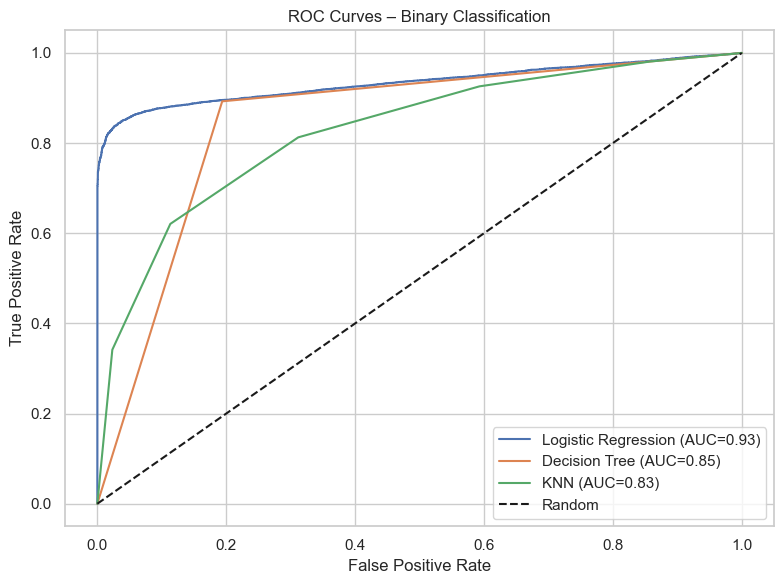

In [22]:
# ROC curves
plt.figure(figsize=(8, 6))

for name, model in binary_models.items():
    y_prob = model.predict_proba(X_test_b)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_b, y_prob)
    auc = roc_auc_score(y_test_b, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Binary Classification')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# classification report for Logistic Regression
print('Classification Report – Logistic Regression (Binary)')
print(classification_report(y_test_b, lr_b.predict(X_test_b), target_names=['No Diabetes', 'Diabetes']))

Classification Report – Logistic Regression (Binary)
              precision    recall  f1-score   support

 No Diabetes       0.84      0.81      0.82      8000
    Diabetes       0.88      0.90      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



### 6B – Multiclass Classification (`diabetes_stage`)

In [24]:
# train three models for multiclass classification
lr_m  = LogisticRegression(max_iter=1000, random_state=42)
dt_m  = DecisionTreeClassifier(random_state=42)
knn_m = KNeighborsClassifier(n_neighbors=5)

for model in [lr_m, dt_m, knn_m]:
    model.fit(X_train_m, y_train_m)

print('Multiclass models trained.')

Multiclass models trained.


In [25]:
# evaluate multiclass models
multi_models = {'Logistic Regression': lr_m, 'Decision Tree': dt_m, 'KNN': knn_m}
multi_results = []

for name, model in multi_models.items():
    y_pred = model.predict(X_test_m)
    multi_results.append({
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_test_m, y_pred), 4),
        'Macro-F1':    round(f1_score(y_test_m, y_pred, average='macro'), 4),
        'Weighted-F1': round(f1_score(y_test_m, y_pred, average='weighted'), 4)
    })

pd.DataFrame(multi_results).set_index('Model')

,Accuracy,Macro-F1,Weighted-F1
Model,,,
Logistic Regression,0.8194,0.4665,0.8162
Decision Tree,0.8549,0.5145,0.8551
KNN,0.6990,0.3629,0.6944


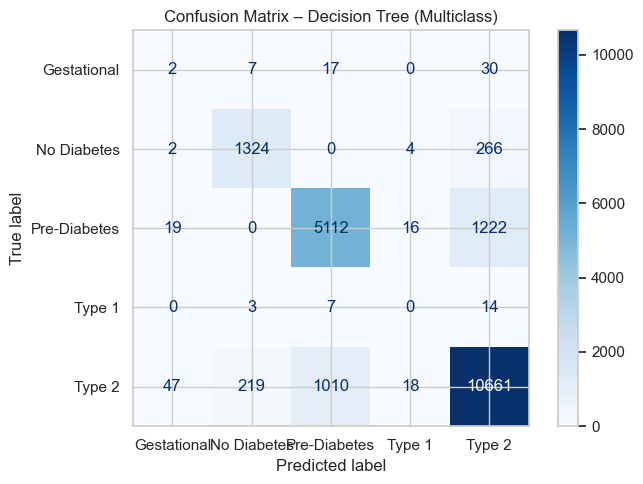

In [26]:
# confusion matrix for Decision Tree (multiclass)
cm = confusion_matrix(y_test_m, dt_m.predict(X_test_m))

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix – Decision Tree (Multiclass)')
plt.tight_layout()
plt.show()

### 6C – Regression (`diabetes_risk_score`)

In [27]:
# train regression models
linreg = LinearRegression()
dt_r   = DecisionTreeRegressor(random_state=42)

linreg.fit(X_train_r, y_train_r)
dt_r.fit(X_train_r, y_train_r)

print('Regression models trained.')

Regression models trained.


In [28]:
# evaluate regression models
reg_models = {'Linear Regression': linreg, 'Decision Tree Regressor': dt_r}
reg_results = []

for name, model in reg_models.items():
    y_pred = model.predict(X_test_r)
    mse = mean_squared_error(y_test_r, y_pred)
    reg_results.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test_r, y_pred), 4),
        'MSE':   round(mse, 4),
        'RMSE':  round(np.sqrt(mse), 4),
        'R2':    round(r2_score(y_test_r, y_pred), 4)
    })

pd.DataFrame(reg_results).set_index('Model')

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,0.4391,0.5543,0.7445,0.9933
Decision Tree Regressor,1.2467,2.5297,1.5905,0.9693


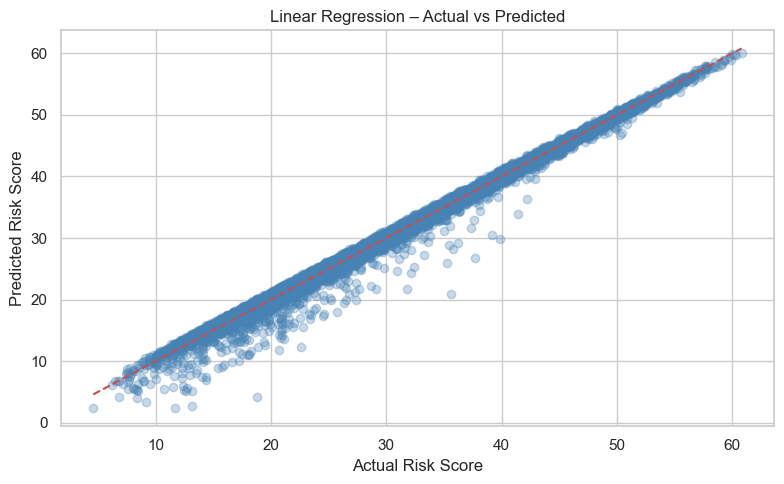

In [29]:
# actual vs predicted for Linear Regression
y_pred_linreg = linreg.predict(X_test_r)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_linreg, alpha=0.3, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel('Actual Risk Score')
plt.ylabel('Predicted Risk Score')
plt.title('Linear Regression – Actual vs Predicted')
plt.tight_layout()
plt.show()

## Phase 7: Hyperparameter Tuning (GridSearchCV)

In [30]:
# tune Decision Tree for binary classification
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

gs_b = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                    cv=5, scoring='f1', n_jobs=-1)
gs_b.fit(X_train_b, y_train_b)

best_dt_b = gs_b.best_estimator_
print('Best params (binary):', gs_b.best_params_)
print('Best CV F1:', round(gs_b.best_score_, 4))

Best params (binary): {'max_depth': 5, 'min_samples_split': 2}
Best CV F1: 0.9299


In [31]:
# tune Decision Tree for multiclass classification
gs_m = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                    cv=5, scoring='f1_macro', n_jobs=-1)
gs_m.fit(X_train_m, y_train_m)

best_dt_m = gs_m.best_estimator_
print('Best params (multiclass):', gs_m.best_params_)
print('Best CV Macro-F1:', round(gs_m.best_score_, 4))

Best params (multiclass): {'max_depth': 5, 'min_samples_split': 10}
Best CV Macro-F1: 0.5501


In [32]:
# tune Decision Tree Regressor
gs_r = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid,
                    cv=5, scoring='r2', n_jobs=-1)
gs_r.fit(X_train_r, y_train_r)

best_dt_r = gs_r.best_estimator_
print('Best params (regression):', gs_r.best_params_)
print('Best CV R2:', round(gs_r.best_score_, 4))

Best params (regression): {'max_depth': None, 'min_samples_split': 10}
Best CV R2: 0.9697


In [33]:
# compare baseline vs tuned performance
comparison = pd.DataFrame({
    'Task': ['Binary (F1)', 'Multiclass (Macro-F1)', 'Regression (R2)'],
    'Baseline': [
        round(f1_score(y_test_b, dt_b.predict(X_test_b)), 4),
        round(f1_score(y_test_m, dt_m.predict(X_test_m), average='macro'), 4),
        round(r2_score(y_test_r, dt_r.predict(X_test_r)), 4)
    ],
    'Tuned': [
        round(f1_score(y_test_b, best_dt_b.predict(X_test_b)), 4),
        round(f1_score(y_test_m, best_dt_m.predict(X_test_m), average='macro'), 4),
        round(r2_score(y_test_r, best_dt_r.predict(X_test_r)), 4)
    ]
})
comparison

,Task,Baseline,Tuned
0,Binary (F1),0.8830,0.9284
1,Multiclass (Macro-F1),0.5145,0.5506
2,Regression (R2),0.9693,0.9719


## Phase 8: Save Final Models

In [34]:
import os
os.makedirs('../models', exist_ok=True)

# save best models
joblib.dump(best_dt_b, '../models/binary_model.joblib')
joblib.dump(best_dt_m, '../models/multiclass_model.joblib')
joblib.dump(best_dt_r, '../models/regression_model.joblib')

# save preprocessing artifacts needed by the Streamlit app
joblib.dump(scaler,                        '../models/scaler.joblib')
joblib.dump(le,                            '../models/label_encoder.joblib')
joblib.dump(X_processed.columns.tolist(),  '../models/feature_names.joblib')

print('All models and artifacts saved to models/.')

All models and artifacts saved to models/.
